---
### Closed-Form Solution with Mass Action Kinetics

Solve for lambda and Y with built-in Python library

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
from joblib import Parallel, delayed
import pandas as pd
import time

# ============================================================
# Parameters
# ============================================================
a = 20.0
k = 0.11
theta_Q = 0.20      # <-- replace by your fitted/fixed housekeeping fraction
N = 120

b_min, b_max = 1e-3, 1e3
b_vals = np.logspace(np.log10(b_min), np.log10(b_max), N)

label_size = 14
title_size = 16
tick_size = 13


### Softmax transformation

In [3]:
# ============================================================
# Softmax partition with fixed housekeeping fraction
# theta_P + theta_R = 1 - theta_Q
# ============================================================
def softmax_partition_HK(u, theta_Q=theta_Q):
    """
    Map a single unconstrained variable u to (theta_P, theta_R)
    with theta_P, theta_R > 0 and theta_P + theta_R = 1 - theta_Q.
    """
    u_val = float(np.atleast_1d(u)[0])
    logZ = logsumexp([u_val, 0.0])

    frac_P = np.exp(u_val - logZ)
    frac_R = np.exp(-logZ)

    scale = 1.0 - theta_Q
    theta_P = scale * frac_P
    theta_R = scale * frac_R
    return theta_P, theta_R

# ============================================================
# Exact steady state for the HK model
#
# Y1* = 1/2 [ sqrt((a theta_R/(b theta_P) + k - 1)^2 + 4k)
#             - (a theta_R/(b theta_P) + k - 1) ]
#
# Y2* = (a theta_R / b) * Y1/(k + Y1)
# Y3* = (a theta_Q theta_R / theta_P) * Y1/(k + Y1)
# Y4* = (a theta_R^2 / theta_P)       * Y1/(k + Y1)
#
# lambda = b Y2*
# ============================================================
def BioSystemHK(theta, b_val, a=a, k=k, theta_Q=theta_Q):
    theta_P, theta_R = map(float, theta)

    if theta_P <= 0.0 or theta_R <= 0.0 or theta_Q <= 0.0 or theta_Q >= 1.0:
        return np.full(8, np.nan)

    z = a * theta_R / (b_val * theta_P)
    sqrt_term = np.sqrt((z + k - 1.0)**2 + 4.0 * k)

    Y1 = 0.5 * (sqrt_term - (z + k - 1.0))
    frac = Y1 / (k + Y1)

    Y2 = (a * theta_R / b_val) * frac
    Y3 = (a * theta_Q * theta_R / theta_P) * frac
    Y4 = (a * theta_R**2 / theta_P) * frac
    lambda_val = b_val * Y2

    return np.array([b_val, theta_P, theta_R, Y1, Y2, Y3, Y4, lambda_val])

def objective_softmax_HK(u, b_val):
    return -BioSystemHK(softmax_partition_HK(u), b_val)[-1]

# ============================================================
# Numerical optimization for each b
# ============================================================
def optimize_for_b_softmax_HK(b_val, tol=1e-10, maxiter=3000):
    # One-dimensional optimization because theta_Q is fixed
    result = minimize(
        lambda u: objective_softmax_HK(u, b_val),
        x0=np.array([0.0]),
        method="Powell",
        tol=tol,
        options={
            "xtol": tol,
            "ftol": tol,
            "maxiter": maxiter,
            "disp": False
        }
    )

    if np.isfinite(result.fun):
        bio_result = BioSystemHK(softmax_partition_HK(result.x), b_val)
        if np.all(np.isfinite(bio_result)) and bio_result[-1] >= 0.0:
            return bio_result

    return None

# ============================================================
# Parallel execution
# ============================================================
start = time.time()
results = Parallel(n_jobs=-1)(
    delayed(optimize_for_b_softmax_HK)(b) for b in b_vals
)
results = np.array([r for r in results if r is not None])

print(f"Optimization completed in {time.time() - start:.2f} seconds.")

# Unpack
(b_arr, thetaP_arr, thetaR_arr, Y1_arr, Y2_arr, Y3_arr, Y4_arr, lambda_arr) = results.T

Optimization completed in 2.72 seconds.


In [4]:
# ============================================================
# DataFrame
# ============================================================
df = pd.DataFrame({
    "b": b_arr,
    "theta_Q": theta_Q,
    "theta_P*": thetaP_arr,
    "theta_R*": thetaR_arr,
    "theta_P* + theta_R*": thetaP_arr + thetaR_arr,
    "1 - theta_Q": (1.0 - theta_Q) * np.ones_like(b_arr),
    "Y1*": Y1_arr,
    "Y2*": Y2_arr,
    "Y3*": Y3_arr,
    "Y4*": Y4_arr,
    "Sum_Y": Y1_arr + Y2_arr + Y3_arr + Y4_arr,
    "lambda*": lambda_arr
})

try:
    from IPython.display import display
    display(df)
except Exception:
    print(df.head())

,b,theta_Q,theta_P*,theta_R*,theta_P* + theta_R*,1 - theta_Q,Y1*,Y2*,Y3*,Y4*,Sum_Y,lambda*
0,0.001000,0.2,0.798088,0.001912,0.8,0.8,0.002340,0.796221,0.000200,0.000002,0.798762,0.000796
1,0.001123,0.2,0.797972,0.002028,0.8,0.8,0.002479,0.795994,0.000224,0.000002,0.798699,0.000894
2,0.001261,0.2,0.797848,0.002152,0.8,0.8,0.002627,0.795752,0.000252,0.000003,0.798634,0.001004
3,0.001417,0.2,0.797717,0.002283,0.8,0.8,0.002784,0.795496,0.000283,0.000003,0.798566,0.001127
4,0.001591,0.2,0.797577,0.002423,0.8,0.8,0.002949,0.795225,0.000317,0.000004,0.798495,0.001265
...,...,...,...,...,...,...,...,...,...,...,...,...
115,628.520327,0.2,0.057761,0.742239,0.8,0.8,0.650260,0.020201,43.963788,163.158220,207.792469,12.696930
116,705.894009,0.2,0.053863,0.746137,0.8,0.8,0.663343,0.018133,47.528789,177.315014,225.525279,12.800142
117,792.792739,0.2,0.050238,0.749762,0.8,0.8,0.676181,0.016268,51.344227,192.479755,244.516431,12.897154
118,890.389094,0.2,0.046868,0.753132,0.8,0.8,0.688759,0.014587,55.425050,208.711891,264.840288,12.988310


### Plot the result

max |theta_P* - theta_P^TP| = 1.895481e-08
max |theta_R* - theta_R^TP| = 1.895481e-08
max relative error in lambda (using TP partition) = 1.034077e-12


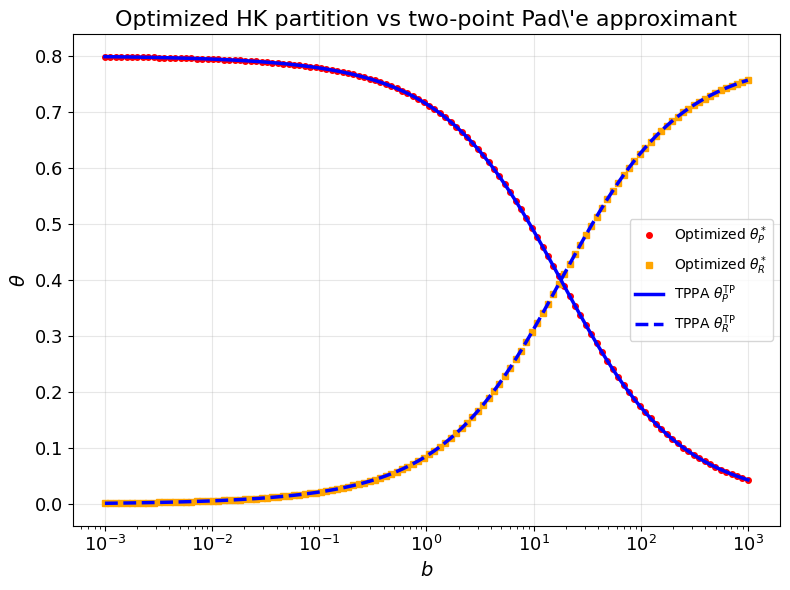

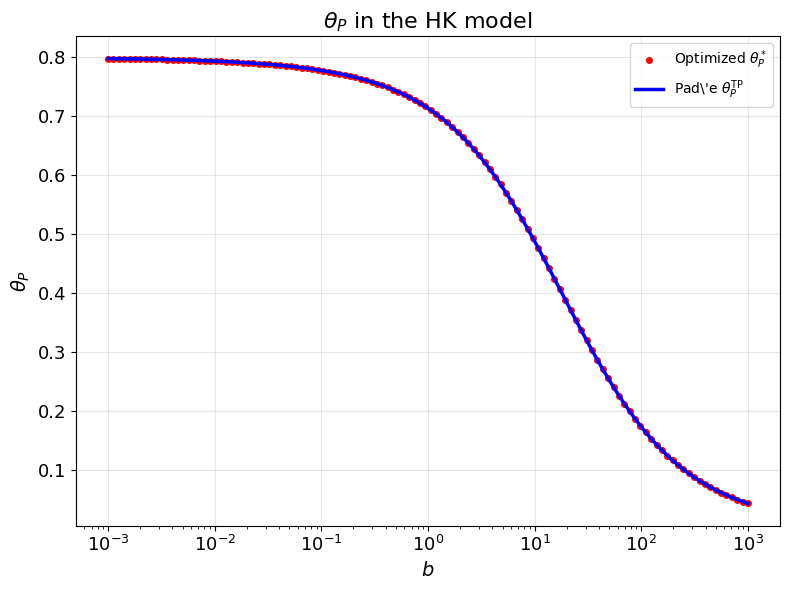

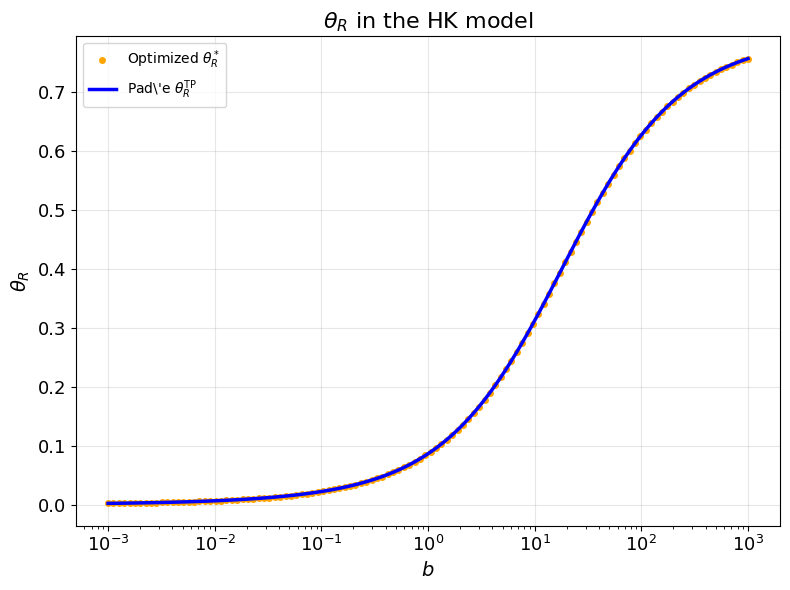

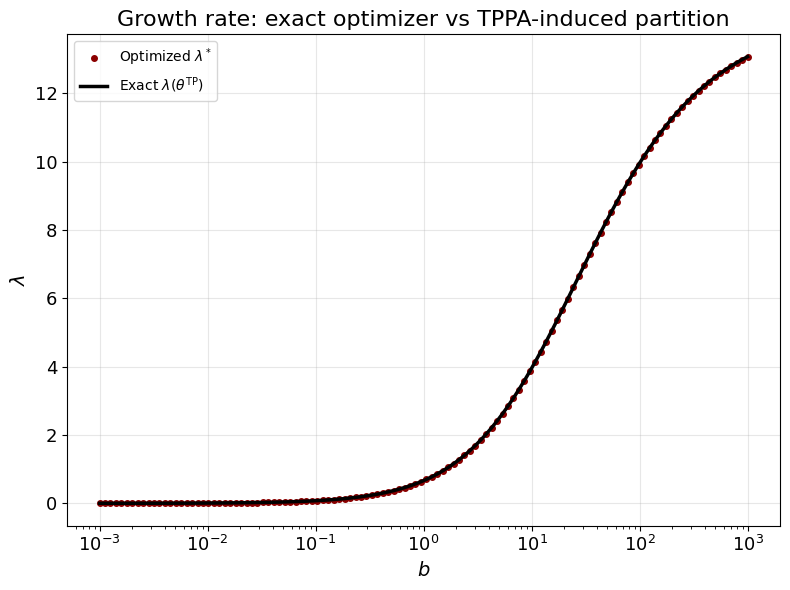

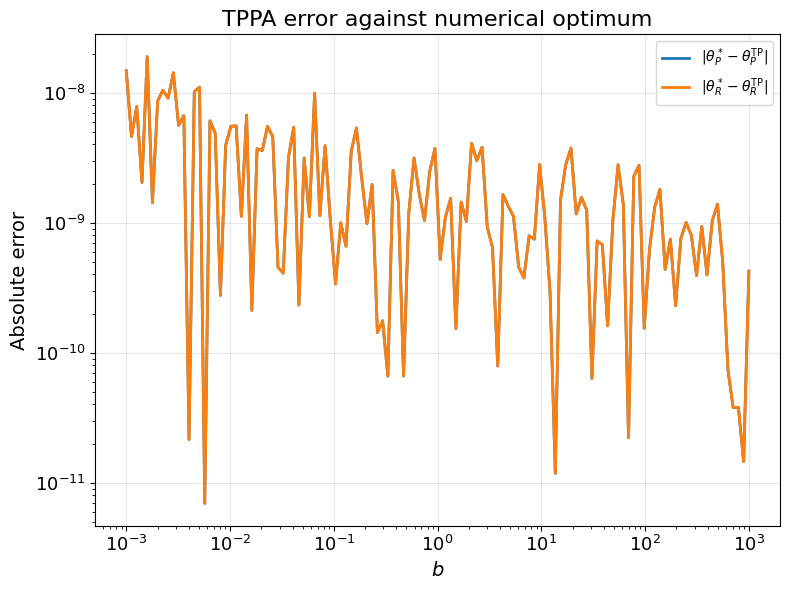

In [5]:
# ============================================================
# Two-point Pade approximant from the HK formula
#
# theta_P^TP = (1-theta_Q) * [1 + sqrt(k/a) sqrt(b)]
#              / [1 + 2 sqrt(k/a) sqrt(b) + ((1+k)/a) b]
#
# theta_R^TP = (1-theta_Q) * [sqrt(k/a) sqrt(b) + ((1+k)/a) b]
#              / [1 + 2 sqrt(k/a) sqrt(b) + ((1+k)/a) b]
# ============================================================
A = np.sqrt(k / a)

def pade_two_point_HK(b, a=a, k=k, theta_Q=theta_Q):
    sqb = np.sqrt(b)
    denom = 1.0 + 2.0 * A * sqb + ((1.0 + k) / a) * b

    theta_P_tp = (1.0 - theta_Q) * (1.0 + A * sqb) / denom
    theta_R_tp = (1.0 - theta_Q) * (A * sqb + ((1.0 + k) / a) * b) / denom
    return theta_P_tp, theta_R_tp

thetaP_TP_arr, thetaR_TP_arr = pade_two_point_HK(b_arr)

# Evaluate the exact growth rate at the TPPA-predicted partition
lambda_TP_arr = np.array([
    BioSystemHK((thP, thR), b)[-1]
    for b, thP, thR in zip(b_arr, thetaP_TP_arr, thetaR_TP_arr)
])

# ============================================================
# Optional error diagnostics
# ============================================================
thetaP_abs_err = np.abs(thetaP_arr - thetaP_TP_arr)
thetaR_abs_err = np.abs(thetaR_arr - thetaR_TP_arr)
lambda_rel_err = np.abs(lambda_arr - lambda_TP_arr) / np.maximum(np.abs(lambda_arr), 1e-14)

print(f"max |theta_P* - theta_P^TP| = {thetaP_abs_err.max():.6e}")
print(f"max |theta_R* - theta_R^TP| = {thetaR_abs_err.max():.6e}")
print(f"max relative error in lambda (using TP partition) = {lambda_rel_err.max():.6e}")

# ============================================================
# Plot 1: optimized partition vs TPPA
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^*$', color='red')
plt.plot(b_arr, thetaR_arr, 's', ms=4, label=r'Optimized $\theta_R^*$', color='orange')

plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'TPPA $\theta_P^{\mathrm{TP}}$', color='blue')
plt.plot(b_arr, thetaR_TP_arr, '--', lw=2.5, label=r'TPPA $\theta_R^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta$', fontsize=label_size)
plt.title(r'Optimized HK partition vs two-point Pad\'e approximant', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: theta_P only
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_arr, 'o', ms=4, label=r'Optimized $\theta_P^*$', color='red')
plt.plot(b_arr, thetaP_TP_arr, '-', lw=2.5, label=r'Pad\'e $\theta_P^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_P$', fontsize=label_size)
plt.title(r'$\theta_P$ in the HK model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: theta_R only
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaR_arr, 'o', ms=4, label=r'Optimized $\theta_R^*$', color='orange')
plt.plot(b_arr, thetaR_TP_arr, '-', lw=2.5, label=r'Pad\'e $\theta_R^{\mathrm{TP}}$', color='blue')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_R$', fontsize=label_size)
plt.title(r'$\theta_R$ in the HK model', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 4: exact optimized growth rate vs TPPA-induced growth rate
# Here lambda_TP_arr is the exact lambda evaluated at the TPPA partition.
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, lambda_arr, 'o', ms=4, label=r'Optimized $\lambda^*$', color='darkred')
plt.plot(b_arr, lambda_TP_arr, '-', lw=2.5,
         label=r'Exact $\lambda(\theta^{\mathrm{TP}})$', color='black')

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\lambda$', fontsize=label_size)
plt.title(r'Growth rate: exact optimizer vs TPPA-induced partition', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 5: absolute partition error of TPPA
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(b_arr, thetaP_abs_err, lw=2, label=r'$|\theta_P^*-\theta_P^{\mathrm{TP}}|$')
plt.plot(b_arr, thetaR_abs_err, lw=2, label=r'$|\theta_R^*-\theta_R^{\mathrm{TP}}|$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'Absolute error', fontsize=label_size)
plt.title(r'TPPA error against numerical optimum', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Changing the Amount of Proteome Allocated to Housekeeping

All theta_Q optimizations completed in 1.72 seconds.


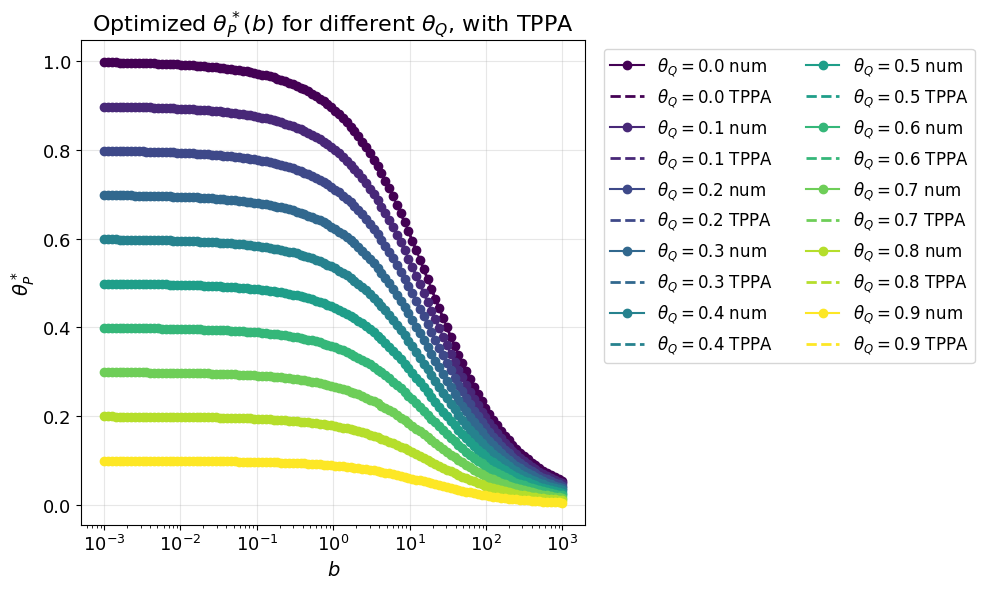

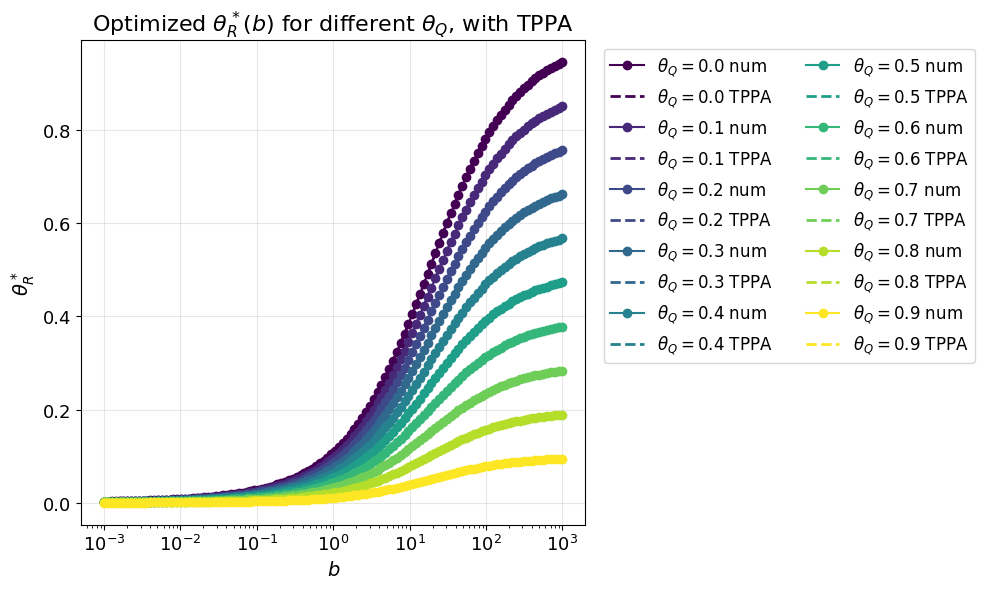

In [15]:
# ============================================================
# Multi-theta_Q plot: numerical optimizer vs TPPA
# plotting theta_P^*(b) for theta_Q = 0.0, 0.1, ..., 0.9
# ============================================================

thetaQ_list = np.round(np.arange(0.0, 1.0, 0.1), 1)

def softmax_partition_HK_thetaQ(u, theta_Q):
    """
    theta_P + theta_R = 1 - theta_Q
    """
    u_val = float(np.atleast_1d(u)[0])
    logZ = logsumexp([u_val, 0.0])
    frac_P = np.exp(u_val - logZ)
    frac_R = np.exp(-logZ)

    scale = 1.0 - theta_Q
    theta_P = scale * frac_P
    theta_R = scale * frac_R
    return theta_P, theta_R

def BioSystemHK_thetaQ(theta, b_val, theta_Q, a=a, k=k):
    theta_P, theta_R = map(float, theta)

    if theta_P <= 0.0 or theta_R <= 0.0 or theta_Q < 0.0 or theta_Q >= 1.0:
        return np.full(8, np.nan)

    term_Y1 = (a * theta_R) / (b_val * theta_P) + k - 1.0
    Y1 = 0.5 * (np.sqrt(term_Y1**2 + 4.0 * k) - term_Y1)

    frac = Y1 / (k + Y1)
    Y2 = (a * theta_R / b_val) * frac
    Y3 = (a * theta_Q * theta_R / theta_P) * frac
    Y4 = (a * theta_R**2 / theta_P) * frac
    lambda_val = b_val * Y2

    return np.array([b_val, theta_P, theta_R, Y1, Y2, Y3, Y4, lambda_val])

def objective_softmax_HK_thetaQ(u, b_val, theta_Q):
    return -BioSystemHK_thetaQ(softmax_partition_HK_thetaQ(u, theta_Q), b_val, theta_Q)[-1]

def optimize_for_b_softmax_HK_thetaQ(b_val, theta_Q, tol=1e-10, maxiter=3000):
    result = minimize(
        lambda u: objective_softmax_HK_thetaQ(u, b_val, theta_Q),
        x0=np.array([0.0]),
        method='Powell',
        tol=tol,
        options={
            'xtol': tol,
            'ftol': tol,
            'maxiter': maxiter,
            'disp': False
        }
    )

    if np.isfinite(result.fun):
        bio_result = BioSystemHK_thetaQ(
            softmax_partition_HK_thetaQ(result.x, theta_Q),
            b_val,
            theta_Q
        )
        if np.all(np.isfinite(bio_result)) and bio_result[-1] >= 0.0:
            return bio_result
    return None

def pade_two_point_HK_thetaQ(b_arr, theta_Q, a=a, k=k):
    A = np.sqrt(k / a)
    denom = 1.0 + 2.0 * A * np.sqrt(b_arr) + ((1.0 + k) / a) * b_arr

    theta_P_tp = (1.0 - theta_Q) * (1.0 + A * np.sqrt(b_arr)) / denom
    theta_R_tp = (1.0 - theta_Q) * (A * np.sqrt(b_arr) + ((1.0 + k) / a) * b_arr) / denom
    return theta_P_tp, theta_R_tp

# store all results if you want to inspect later
multi_thetaQ_results = {}

start = time.time()
for theta_Q_i in thetaQ_list:
    results_i = Parallel(n_jobs=-1)(
        delayed(optimize_for_b_softmax_HK_thetaQ)(b, theta_Q_i) for b in b_vals
    )
    results_i = np.array([r for r in results_i if r is not None])

    if len(results_i) == 0:
        continue

    (b_arr_i, thetaP_arr_i, thetaR_arr_i, Y1_arr_i, Y2_arr_i, Y3_arr_i, Y4_arr_i, lambda_arr_i) = results_i.T
    thetaP_TP_i, thetaR_TP_i = pade_two_point_HK_thetaQ(b_arr_i, theta_Q_i)

    multi_thetaQ_results[theta_Q_i] = {
        "b": b_arr_i,
        "thetaP_num": thetaP_arr_i,
        "thetaR_num": thetaR_arr_i,
        "thetaP_tppa": thetaP_TP_i,
        "thetaR_tppa": thetaR_TP_i,
        "lambda": lambda_arr_i
    }

print(f"All theta_Q optimizations completed in {time.time() - start:.2f} seconds.")

# ============================================================
# Plot all theta_P curves in one figure
# solid = numerical optimum
# dashed = TPPA
# ============================================================
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    plt.plot(
        data_i["b"], data_i["thetaP_num"],
        marker='o', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ num'
    )
    plt.plot(
        data_i["b"], data_i["thetaP_tppa"],
        lw=2, ls='--', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ TPPA'
    )

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_P^*$', fontsize=label_size)
plt.title(r'Optimized $\theta_P^*(b)$ for different $\theta_Q$, with TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# Plot all theta_R curves in one figure
# solid = numerical optimum
# dashed = TPPA
# ============================================================
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    plt.plot(
        data_i["b"], data_i["thetaR_num"],
        marker='o', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ num'
    )
    plt.plot(
        data_i["b"], data_i["thetaR_tppa"],
        lw=2, ls='--', color=c,
        label=fr'$\theta_Q={theta_Q_i:.1f}$ TPPA'
    )

plt.xscale('log')
plt.xlabel(r'$b$', fontsize=label_size)
plt.ylabel(r'$\theta_R^*$', fontsize=label_size)
plt.title(r'Optimized $\theta_R^*(b)$ for different $\theta_Q$, with TPPA', fontsize=title_size)
plt.tick_params(axis='both', which='major', labelsize=tick_size)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Organize Everything Into One Plot

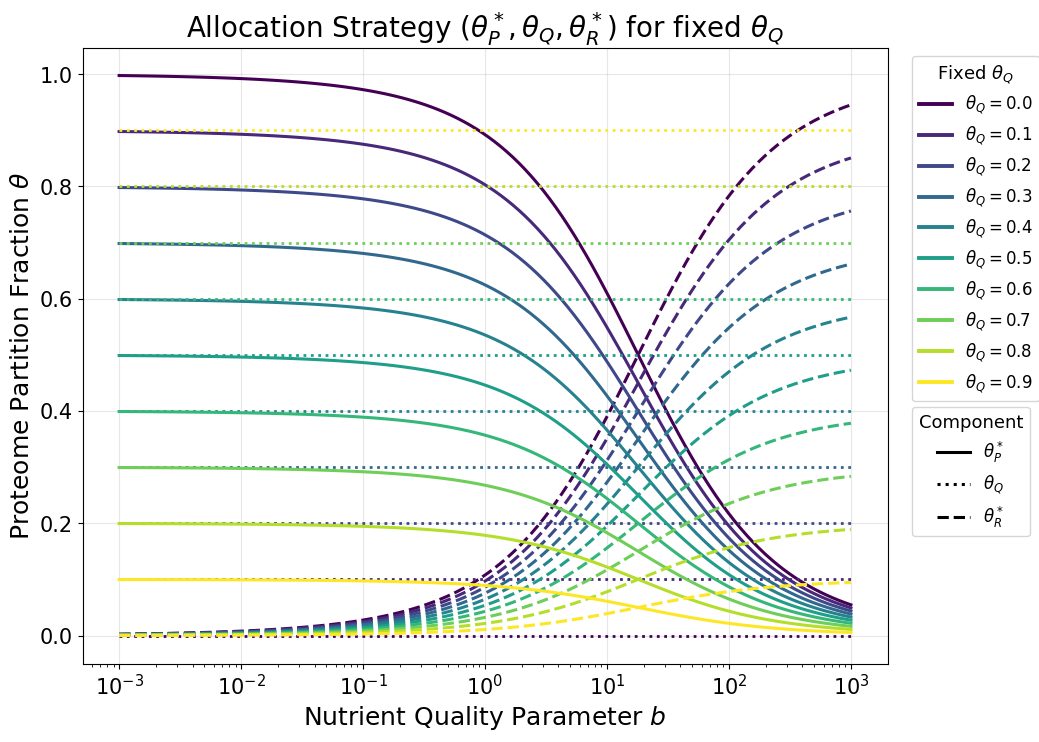

In [30]:
from matplotlib.lines import Line2D

# ============================================================
# Plot theta_P, theta_Q, theta_R together
# for theta_Q = 0.0, 0.1, ..., 0.9
# ============================================================
fig, ax = plt.subplots(figsize=(14, 8))   # wider figure
colors = plt.cm.viridis(np.linspace(0, 1, len(thetaQ_list)))

for c, theta_Q_i in zip(colors, thetaQ_list):
    if theta_Q_i not in multi_thetaQ_results:
        continue

    data_i = multi_thetaQ_results[theta_Q_i]
    b_i = data_i["b"]
    thetaP_i = data_i["thetaP_num"]
    thetaR_i = data_i["thetaR_num"]
    thetaQ_i_arr = np.full_like(b_i, theta_Q_i)

    # theta_P^*(b)
    ax.plot(b_i, thetaP_i, color=c, lw=2.2, ls='-')

    # theta_Q (constant)
    ax.plot(b_i, thetaQ_i_arr, color=c, lw=2.0, ls=':')

    # theta_R^*(b)
    ax.plot(b_i, thetaR_i, color=c, lw=2.2, ls='--')

ax.set_xscale('log')
ax.set_xlabel(r'Nutrient Quality Parameter $b$', fontsize=18)
ax.set_ylabel(r'Proteome Partition Fraction $\theta$', fontsize=18)
ax.set_title(r'Allocation Strategy $(\theta_P^*, \theta_Q, \theta_R^*)$ for fixed $\theta_Q$', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.grid(True, alpha=0.3)

# Legend 1: colors correspond to theta_Q values
color_handles = [
    Line2D([0], [0], color=c, lw=2.8, label=fr'$\theta_Q={theta_Q_i:.1f}$')
    for c, theta_Q_i in zip(colors, thetaQ_list)
]

# Legend 2: line styles correspond to components
style_handles = [
    Line2D([0], [0], color='black', lw=2.2, ls='-',  label=r'$\theta_P^*$'),
    Line2D([0], [0], color='black', lw=2.2, ls=':',  label=r'$\theta_Q$'),
    Line2D([0], [0], color='black', lw=2.2, ls='--', label=r'$\theta_R^*$'),
]

legend1 = ax.legend(
    handles=color_handles,
    title=r'Fixed $\theta_Q$',
    fontsize=12,
    title_fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.00),
    frameon=True
)
ax.add_artist(legend1)

ax.legend(
    handles=style_handles,
    title='Component',
    fontsize=12,
    title_fontsize=13,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.43),
    frameon=True
)

# Reserve space on the right for the legends
fig.subplots_adjust(right=0.7)

plt.show()